#Análsis Post-Lectura

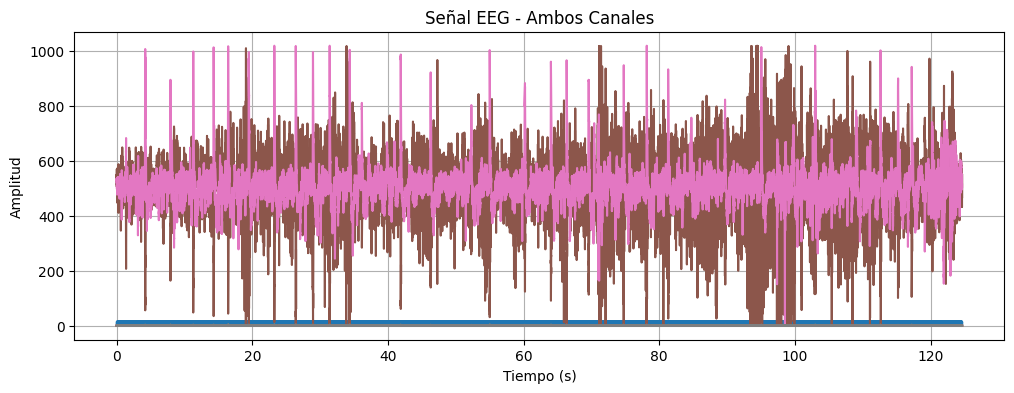

In [2]:
import numpy as np
import matplotlib.pyplot as plt
# Leer archivo
eeg = np.loadtxt("lectura-post-Jose.txt")

# Frecuencia de muestreo
fs = 1000

# Vector de tiempo
t = np.arange(len(eeg)) / fs

# Graficar ambos canales
plt.figure(figsize=(12,4))
plt.plot(t, eeg)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("Señal EEG - Ambos Canales")
plt.grid()
plt.show()

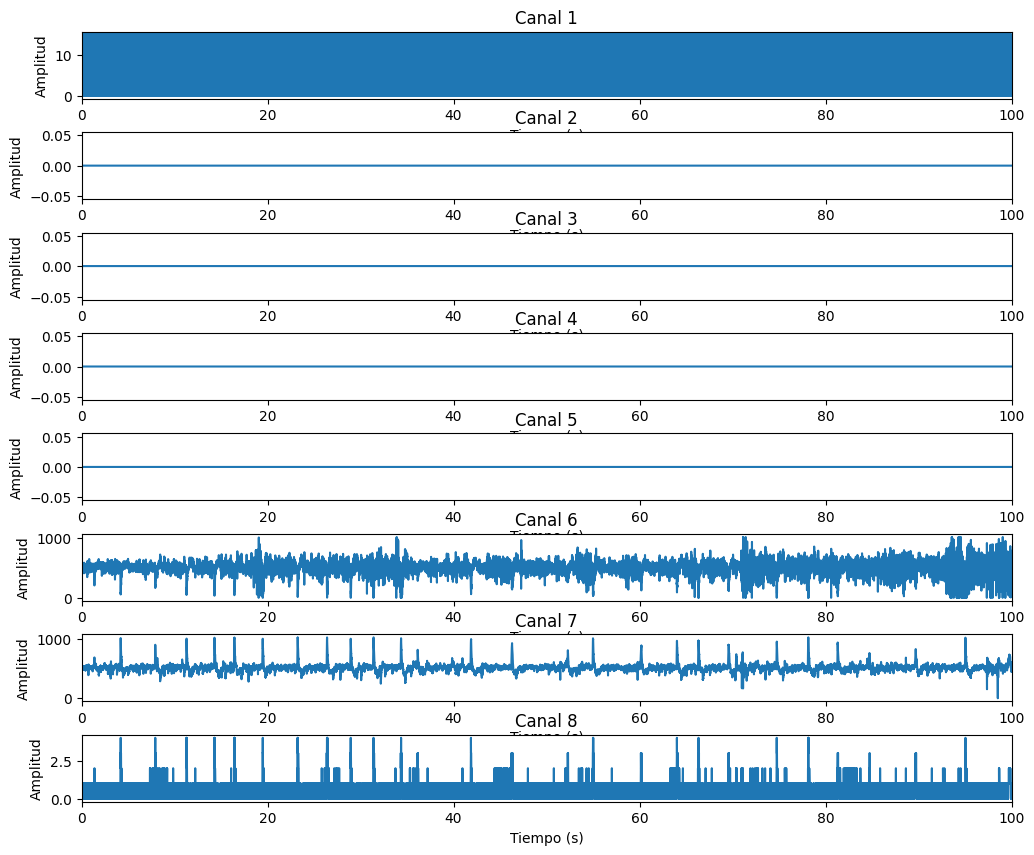

In [4]:
import pandas as pd
df = pd.DataFrame(eeg.T)
min1=0
max1=100

plt.figure(figsize=(12,10))

for i in range(df.shape[0]):
  plt.subplot(8,1,i+1)
  plt.plot(t, df.iloc[i,:])
  plt.title("Canal " + str(i+1))
  plt.xlabel("Tiempo (s)")
  plt.ylabel("Amplitud")
  plt.xlim(min1, max1)

plt.subplots_adjust(hspace=0.5)
plt.show()

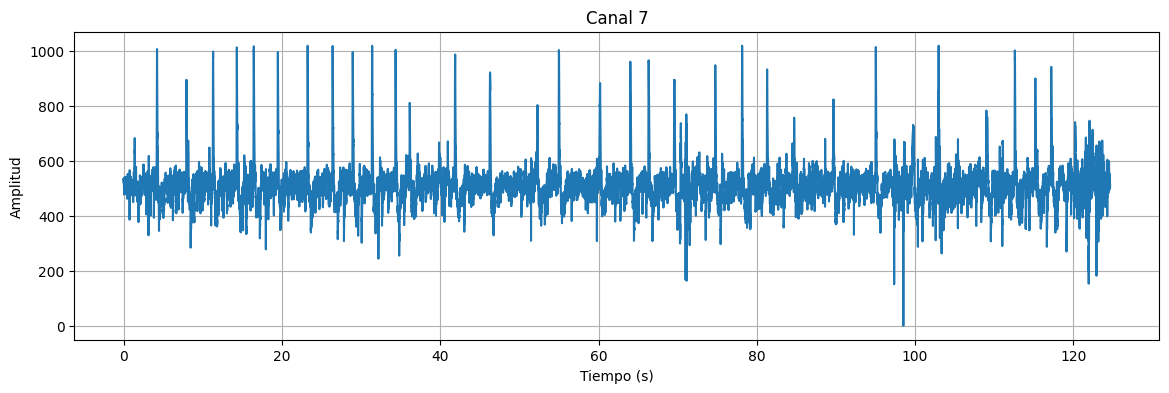

In [5]:
eeg = np.loadtxt("lectura-post-Jose.txt")

fs = 1000

canal7 = eeg[:,6]

t = np.arange(len(canal7))/fs

plt.figure(figsize=(14,4))
plt.plot(t, canal7)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("Canal 7")
plt.grid(True)
plt.show()

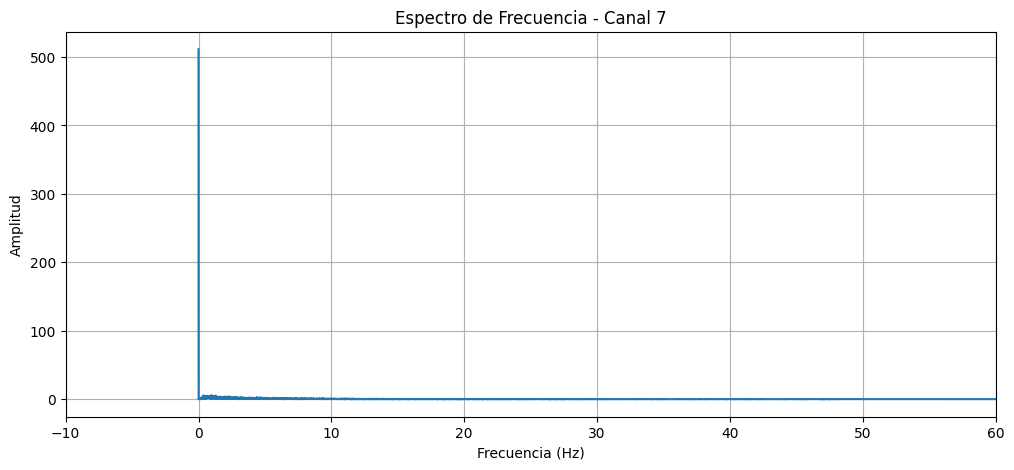

In [6]:
N = len(canal7)

fft_vals = np.fft.rfft(canal7)
freqs = np.fft.rfftfreq(N, 1/fs)

amplitud = np.abs(fft_vals)/N

plt.figure(figsize=(12,5))
plt.plot(freqs, amplitud)
plt.xlabel("Frecuencia (Hz)")
plt.xlim(-10,60)
plt.ylabel("Amplitud")
plt.title("Espectro de Frecuencia - Canal 7")
plt.grid(True)
plt.show()

Text(0.5, 1.0, 'Canal 7 sin componente DC')

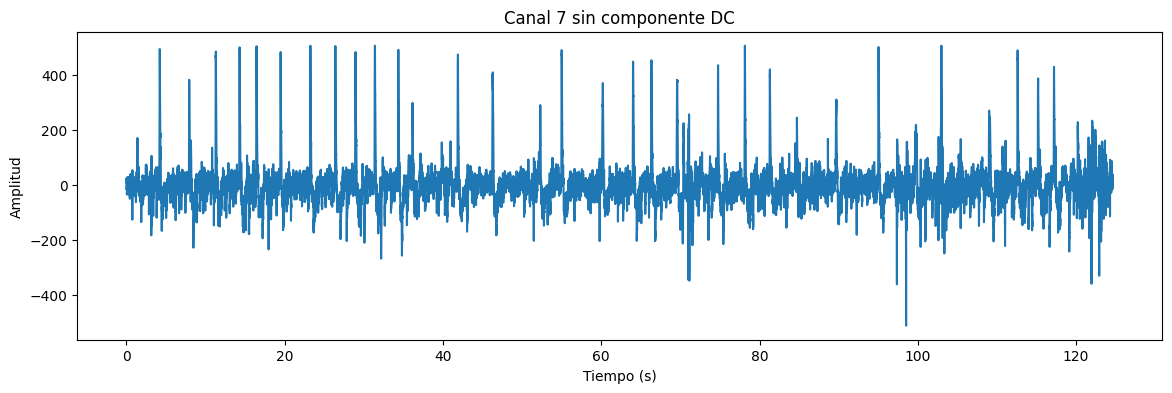

In [7]:
canal7 = canal7 - np.mean(canal7)
plt.figure(figsize=(14,4))
plt.plot(t, canal7)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("Canal 7 sin componente DC")

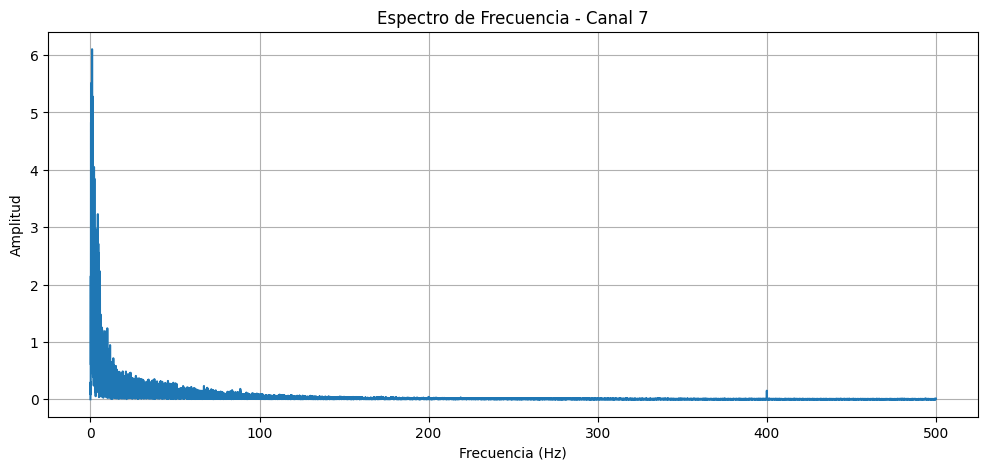

In [8]:
N = len(canal7)

fft_vals = np.fft.rfft(canal7)
freqs = np.fft.rfftfreq(N, 1/fs)

amplitud = np.abs(fft_vals)/N

plt.figure(figsize=(12,5))
plt.plot(freqs, amplitud)
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Amplitud")
plt.title("Espectro de Frecuencia - Canal 7")
plt.grid(True)
plt.show()

In [9]:
from scipy.signal import butter, filtfilt, iirnotch

# Filtro pasa banda 0.5–100 Hz
low = 0.5
high = 100

b, a = butter(4, [low/(fs/2), high/(fs/2)], btype='band')
canal_filtrado = filtfilt(b, a, canal7)

# Notch 60 Hz si estás en Perú; también puedes usar 50 Hz según tu red/equipo
f0 = 60
Q = 30
b_notch, a_notch = iirnotch(f0/(fs/2), Q)
canal_filtrado = filtfilt(b_notch, a_notch, canal_filtrado)

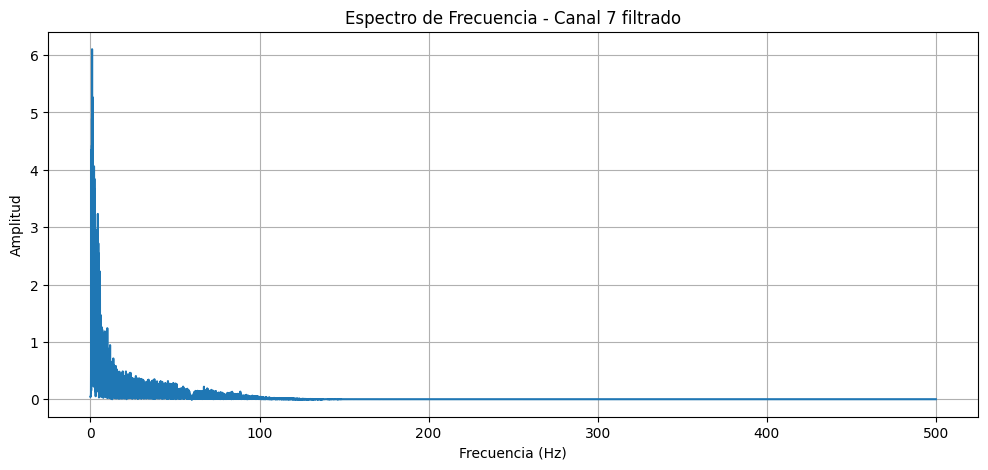

In [10]:
N = len(canal_filtrado)

fft_vals = np.fft.rfft(canal_filtrado)
freqs = np.fft.rfftfreq(N, 1/fs)

amplitud = np.abs(fft_vals) / N

plt.figure(figsize=(12,5))
plt.plot(freqs, amplitud)
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Amplitud")
plt.title("Espectro de Frecuencia - Canal 7 filtrado")
plt.grid(True)
plt.show()

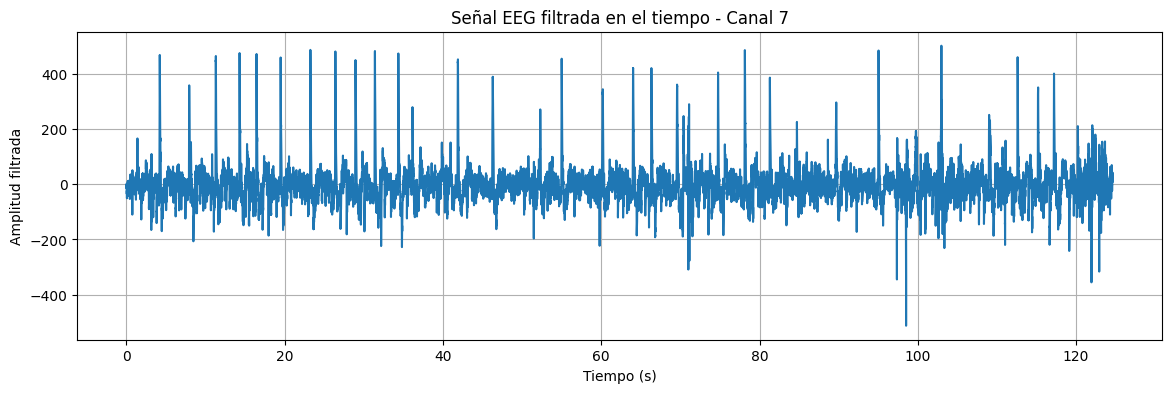

In [11]:
t = np.arange(len(canal_filtrado)) / fs

plt.figure(figsize=(14,4))
plt.plot(t, canal_filtrado)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud filtrada")
plt.title("Señal EEG filtrada en el tiempo - Canal 7")
plt.grid(True)
plt.show()

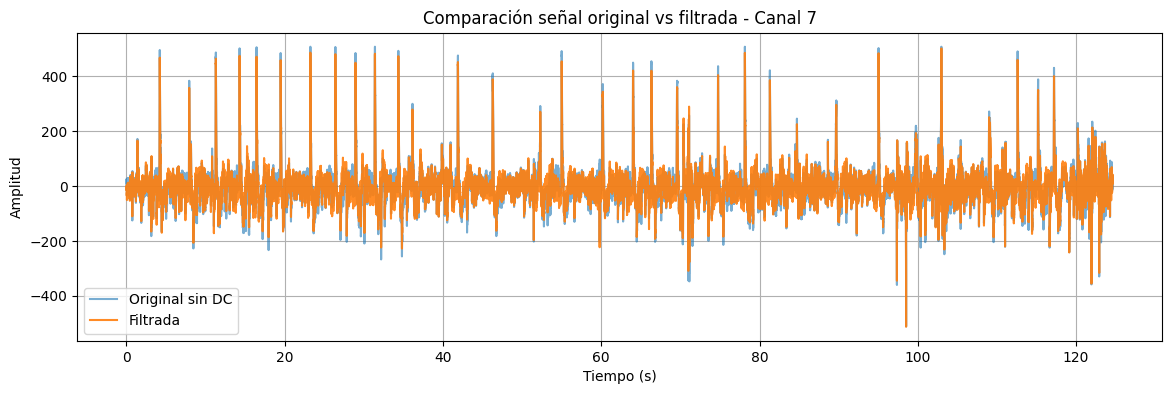

In [12]:
plt.figure(figsize=(14,4))
plt.plot(t, canal7, label="Original sin DC", alpha=0.6)
plt.plot(t, canal_filtrado, label="Filtrada", alpha=0.9)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("Comparación señal original vs filtrada - Canal 7")
plt.legend()
plt.grid(True)
plt.show()

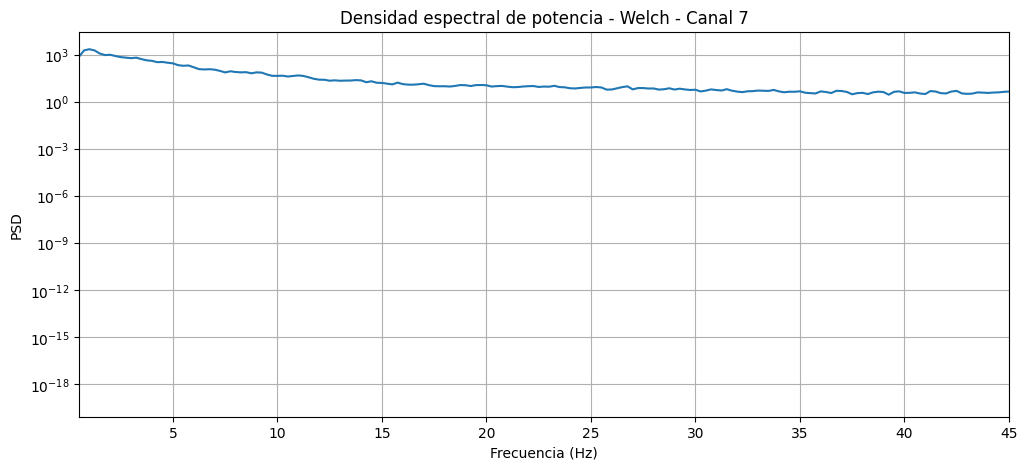

In [13]:
from scipy.signal import welch
import numpy as np
import matplotlib.pyplot as plt

# Welch
f, psd = welch(
    canal_filtrado,
    fs=fs,
    window='hann',
    nperseg=4*fs,      # ventana de 4 segundos
    noverlap=2*fs,     # 50% de solapamiento
    scaling='density'
)

plt.figure(figsize=(12,5))
plt.semilogy(f, psd)
plt.xlim(0.5, 45)
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("PSD")
plt.title("Densidad espectral de potencia - Welch - Canal 7")
plt.grid(True)
plt.show()

/tmp/ipykernel_3534/3573531341.py:13: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  potencia = np.trapz(psd[idx], f[idx])


Delta: 3324.4752
Theta: 711.8825
Alpha: 224.8959
Beta: 176.1498
Gamma baja: 61.6782


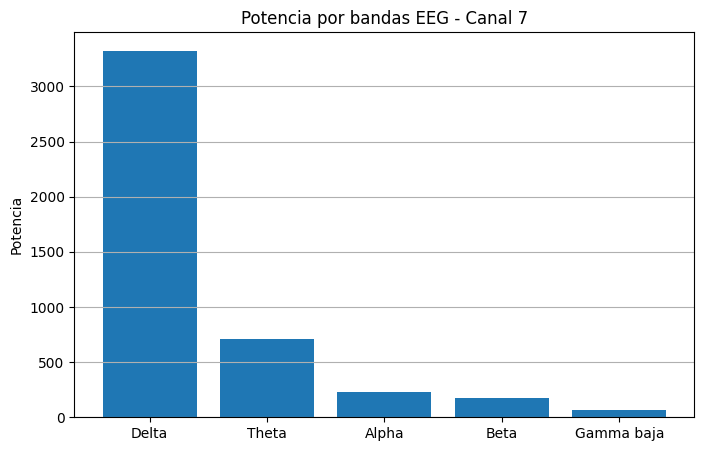

In [14]:
bandas = {
    "Delta": (0.5, 4),
    "Theta": (4, 8),
    "Alpha": (8, 13),
    "Beta": (13, 30),
    "Gamma baja": (30, 45)
}

potencias = {}

for nombre, (fmin, fmax) in bandas.items():
    idx = np.logical_and(f >= fmin, f < fmax)
    potencia = np.trapz(psd[idx], f[idx])
    potencias[nombre] = potencia

for banda, potencia in potencias.items():
    print(f"{banda}: {potencia:.4f}")

plt.figure(figsize=(8,5))
plt.bar(potencias.keys(), potencias.values())
plt.ylabel("Potencia")
plt.title("Potencia por bandas EEG - Canal 7")
plt.grid(axis='y')
plt.show()